In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse
from collections import Counter
from vectorization.vectorizer_selector import VectorizerSelector
from vectorization.bow import BoWVectorizer
from vectorization.tfidf import TfidfVectorizerWrapper

In [5]:
df = pd.read_pickle("../results/preprocessed.pkl")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50000, 3)


,review,sentiment,cleaned
0,One of the other reviewers has mentioned that ...,positive,"[one, reviewer, mentioned, watching, oz, episo..."
1,A wonderful little production. <br /><br />The...,positive,"[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,"[basically, family, little, boy, jake, think, ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"[petter, mattei, love, time, money, visually, ..."


In [ ]:
sys.path.append(os.path.abspath(".."))


bow_vectorizer = BoWVectorizer()
X_bow = bow_vectorizer.fit_transform(df)

tfidf_vectorizer = TfidfVectorizerWrapper()
X_tfidf = tfidf_vectorizer.fit_transform(df)

scipy.sparse.save_npz("../results/X_bow.npz", X_bow)
scipy.sparse.save_npz("../results/X_tfidf.npz", X_tfidf)

with open("../results/bow_vectorizer.pkl", "wb") as f:
    pickle.dump(bow_vectorizer, f)

with open("../results/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print("Matrices saved as .npz (sparse format)")
print("Vectorizers saved as .pkl (pickle format)")

Matrices saved as .npz (sparse format)
Vectorizers saved as .pkl (pickle format)


In [7]:
print("BoW matrix shape:", X_bow.shape)
print("TF-IDF matrix shape:", X_tfidf.shape)

BoW matrix shape: (50000, 90607)
TF-IDF matrix shape: (50000, 90607)


In [8]:
word_counts = np.asarray(X_bow.sum(axis=0)).flatten()
words = bow_vectorizer.vectorizer.get_feature_names_out()

count_df = pd.DataFrame({'word': words, 'count': word_counts})
count_df = count_df.sort_values(by='count', ascending=False)
bow_top_20 = count_df.head(20)
bow_top_20

,word,count
53069,movie,101149
28466,film,91584
56664,one,54293
46264,like,40875
80588,time,30566
32870,good,29360
13074,character,27889
89082,would,26624
76261,story,24745
26297,even,24562


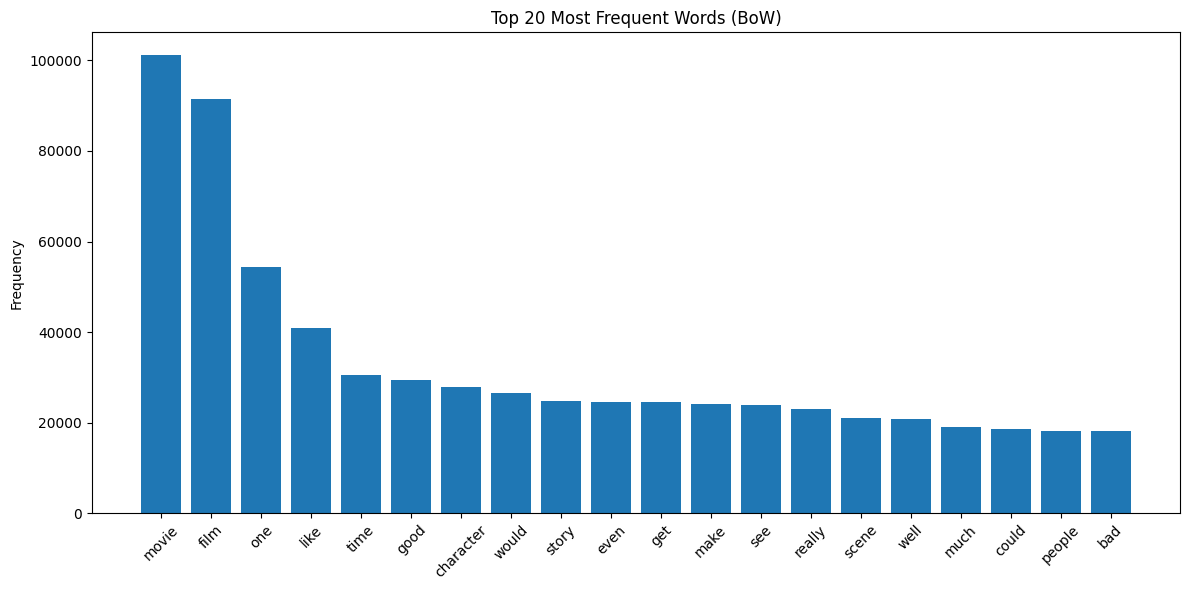

In [9]:
plt.figure(figsize=(12, 6))
plt.bar(bow_top_20['word'], bow_top_20['count'])
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words (BoW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [10]:
word_scores = np.asarray(X_tfidf.mean(axis=0)).flatten()
words = tfidf_vectorizer.vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({'word': words, 'tfidf_score': word_scores})
freq_df = freq_df.sort_values(by='tfidf_score', ascending=False)
top_tfidf = freq_df.head(20)
top_tfidf

,word,tfidf_score
53069,movie,0.053182
28466,film,0.043868
56664,one,0.026497
46264,like,0.022712
32870,good,0.019886
80588,time,0.018832
13074,character,0.017826
89082,would,0.017477
76261,story,0.017333
64813,really,0.017036


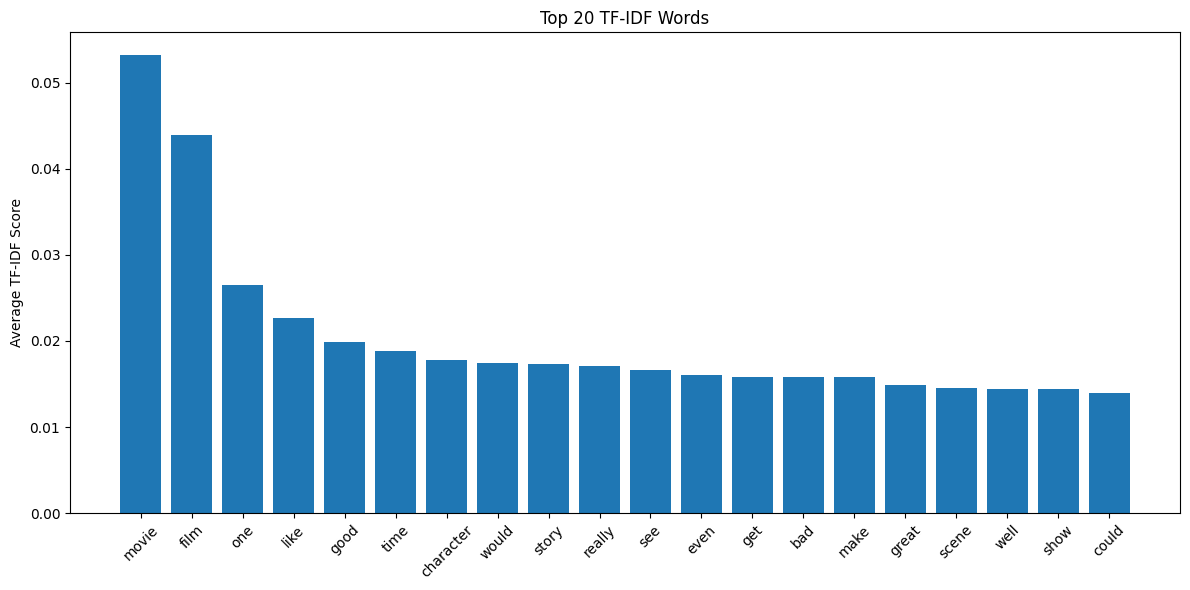

In [11]:
plt.figure(figsize=(12, 6))
plt.bar(top_tfidf['word'], top_tfidf['tfidf_score'])
plt.xticks(rotation=45)
plt.title("Top 20 TF-IDF Words")
plt.ylabel("Average TF-IDF Score")
plt.tight_layout()
plt.show()

In [12]:
selected_words = bow_top_20.head(10)['word'].tolist()
selected_word_indices = [
    bow_vectorizer.vectorizer.vocabulary_[word]
    for word in selected_words
]


bow_subset = pd.DataFrame(
    X_bow[:5, selected_word_indices].toarray(),
    columns=selected_words
)
bow_subset.index = [f"Review {i}" for i in range(1, 6)]
bow_subset

,movie,film,one,like,time,good,character,would,story,even
Review 1,0,0,1,0,0,0,0,2,0,0
Review 2,0,0,1,0,1,0,0,0,0,0
Review 3,0,0,1,0,1,0,1,0,0,1
Review 4,3,2,0,1,0,0,0,0,0,0
Review 5,1,2,6,0,2,2,2,0,0,0


In [13]:
tfidf_subset = pd.DataFrame(
    X_tfidf[:5, selected_word_indices].toarray(),
    columns=selected_words
)
tfidf_subset.index = [f"Review {i}" for i in range(1, 6)]
tfidf_subset

,movie,film,one,like,time,good,character,would,story,even
Review 1,0.000000,0.000000,0.018596,0.000000,0.000000,0.000000,0.000000,0.049392,0.0,0.000000
Review 2,0.000000,0.000000,0.028705,0.000000,0.035348,0.000000,0.000000,0.000000,0.0,0.000000
Review 3,0.000000,0.000000,0.032451,0.000000,0.039961,0.000000,0.044072,0.000000,0.0,0.043783
Review 4,0.089324,0.063928,0.000000,0.036355,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
Review 5,0.021734,0.046664,0.141307,0.000000,0.058003,0.059589,0.063970,0.000000,0.0,0.000000


In [14]:
# Broj dokumenata u kojima se svaka rec pojavljuje (= min_df logika)
doc_freq = np.asarray((X_bow > 0).sum(axis=0)).flatten()
words = bow_vectorizer.vectorizer.get_feature_names_out()

doc_freq_df = pd.DataFrame({'word': words, 'doc_count': doc_freq.astype(int)})

print(f"Total unique words: {len(doc_freq_df)}")
print(f"\nWords in only 1 document:  {(doc_freq_df['doc_count'] == 1).sum()}")
print(f"Words in only 2 documents: {(doc_freq_df['doc_count'] == 2).sum()}")
print(f"Words in only 3 documents: {(doc_freq_df['doc_count'] == 3).sum()}")
print(f"Words in only 4 documents: {(doc_freq_df['doc_count'] == 4).sum()}")
print(f"Words in ≤5 documents:     {(doc_freq_df['doc_count'] <= 5).sum()}")

Total unique words: 90607

Words in only 1 document:  38970
Words in only 2 documents: 10350
Words in only 3 documents: 5531
Words in only 4 documents: 3838
Words in ≤5 documents:     61400


In [15]:
print("Examples of words in only 1 document:")
rare = doc_freq_df[doc_freq_df['doc_count'] == 1].sample(20, random_state=42)
print(rare['word'].tolist())

print("\nExamples of words in only 2 documents:")
rare2 = doc_freq_df[doc_freq_df['doc_count'] == 2].sample(20, random_state=42)
print(rare2['word'].tolist())

Examples of words in only 1 document:
['pigot', 'hounslow', 'memorializes', 'imac', 'avoide', 'ofevery', 'starrings', 'cofffeenut', 'moshana', 'doods', 'nerdlebrain', 'greuesome', 'cagliostro', 'interdimensional', 'agra', 'ayats', 'wheatlands', 'slainte', 'osaurus', 'blondel']

Examples of words in only 2 documents:
['zeferelli', 'rychard', 'stalactite', 'pyroclastic', 'atrium', 'shayesteh', 'hamdan', 'heartbreaker', 'gwoemul', 'afaik', 'fundament', 'prolongs', 'mistakingly', 'dejection', 'gorbachev', 'liebestod', 'seekwet', 'shimkus', 'absconding', 'buttered']


min_df=1: vocabulary size = 90,607
min_df=2: vocabulary size = 51,637
min_df=3: vocabulary size = 41,287
min_df=5: vocabulary size = 31,918
min_df=10: vocabulary size = 22,597


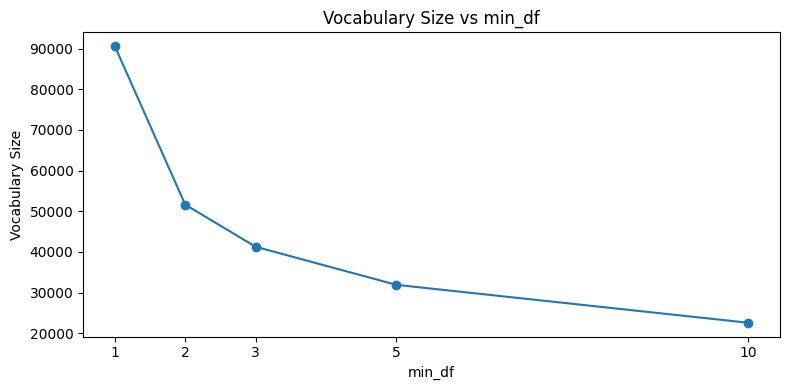

In [16]:
min_dfs = [1, 2, 3, 5, 10]
vocab_sizes = []

for min_df in min_dfs:
    selector = VectorizerSelector(method='bow', min_df=min_df)
    bow = selector.get_vectorizer()
    X = bow.fit_transform(df)
    vocab_sizes.append(X.shape[1])
    print(f"min_df={min_df}: vocabulary size = {X.shape[1]:,}")

plt.figure(figsize=(8, 4))
plt.plot(min_dfs, vocab_sizes, marker='o')
plt.title('Vocabulary Size vs min_df')
plt.xlabel('min_df')
plt.ylabel('Vocabulary Size')
plt.xticks(min_dfs)
plt.tight_layout()
plt.show()